In [2]:
# import libraries
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# parameter set up
sys.path.insert(0, "..")
base_dir = os.path.dirname(os.path.abspath("__file__"))

### Data Collection

` New Release Data`
* step 1: scrapting news release from WM website
* step 2: extract guidance-related section(.csv) from news release (.pdf)
* step 3: Using Ollama + llama3.2 to parse structured guidance fields from prepared scv

In [3]:
base_url = "https://investors.wm.com"
page_url = "https://investors.wm.com/financials/financial-results"
save_dir = os.path.join(base_dir, "../data/raw/news_releases")

In [ ]:
# scrape news release data
from src.web_scraper import WMNewsReleaseScraper

scraper = WMNewsReleaseScraper(base_url=base_url, page_url=page_url, save_dir=save_dir)
scraper.run()

Loading https://investors.wm.com/financials/financial-results ...
Found 20 news release PDFs.
[1/20] Downloading 1Q_2025_Press_Release_Final_Consolidated.pdf
  Saved: /Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/1Q_2025_Press_Release_Final_Consolidated.pdf
[2/20] Downloading 2Q_2025_Press_Release_Final_Consolidated.pdf
  Saved: /Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/2Q_2025_Press_Release_Final_Consolidated.pdf
[3/20] Downloading 3Q_2025_Press_Release_Consolidated.pdf
  Saved: /Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/3Q_2025_Press_Release_Consolidated.pdf
[4/20] Downloading 4Q_Consolidated_Press_Release.pdf
  Saved: /Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/4Q_Consolidated_Press_Release.pdf
[5/20] Downloading 1Q_2024_Press_Release_Final_Consolidated.pdf
  Saved: /Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw

['/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/1Q_2025_Press_Release_Final_Consolidated.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/2Q_2025_Press_Release_Final_Consolidated.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/3Q_2025_Press_Release_Consolidated.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/4Q_Consolidated_Press_Release.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/1Q_2024_Press_Release_Final_Consolidated.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/2Q_2024_Press_Release_Final_Consolidated.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/3Q_2024_Press_Release_10-27-24_Final_Consolidated.pdf',
 '/Users/chenyao/Downloads/otpp_tech_assessment/notebooks/../data/raw/news_releases/4Q_2024

In [7]:
# extract sections of interest from news release pdfs
from src.pdf_extractor import SectionExtractor

pdf_files = [f for f in os.listdir(save_dir) if f.endswith('.pdf')]
data = []

for pdf_file in pdf_files:

    pdf_path = os.path.join(save_dir, pdf_file)
    
    result = SectionExtractor(pdf_path, "OUTLOOK|EXPECTATIONS|GUIDANCE")
    context = result["text"]
    section = result["section"]
    fiscal_year  = result["fiscal_year"]
    fiscal_quarter = result["fiscal_quarter"]
    release_date = result["release_date"]
    
    data.append({'fiscal_year': fiscal_year, 'fiscal_quarter': fiscal_quarter, 'release_date': release_date, 'file': pdf_file, 'section': section, 'context': context})


In [8]:
# create guidance dataframe and clean data
df_extracted = pd.DataFrame(data).sort_values(by='release_date', ascending=True).dropna(subset=['section'])
df_extracted.replace('', np.nan, inplace=True)
df_extracted.dropna(subset=['context'], inplace=True)
df_extracted.reset_index(drop=True, inplace=True)
df_extracted.head(5)

,fiscal_year,fiscal_quarter,release_date,file,section,context
0,2021,Q1,20210427,1Q_2021_Press_Release_04-26-21_Final_Consolida...,OUTLOOK,Total Company revenue growth is expected to be...
1,2021,Q2,20210727,2Q_2021_Press_Release_Final_Consolidated.pdf,REVISED 2021 OUTLOOK,Total Company revenue growth in 2021 is expect...
2,2021,Q3,20211026,3Q_2021_Press_Release_Final_Consolidated.pdf,2021 OUTLOOK,Total Company revenue growth in 2021 is expect...
3,2021,Q4,20220202,4Q_2021_Press_Release_02_01_22_Final_Consolida...,2022 OUTLOOK,Revenue Growth\nTotal Company revenue growth i...
4,2022,Q2,20220727,2Q_2022_Press_Release_Final_07_26_2022_consoli...,REVISED 2022 OUTLOOK,Total Company revenue growth in 2022 is expect...


In [20]:
# extract revenue & fcf- related sentences only
def extract_sentences(text):
    if not isinstance(text, str):
        return ""
    sentences = re.split(r'(?<=[.!?])\s+|\n', text)
    filtered = [s for s in sentences if re.search(r'\brevenue\b|\bfree cash flow\b|\bmillions?\b|\bbillions?\b', s, re.IGNORECASE)]
    return ' '.join(filtered)

df_filtered = df_extracted.copy()
df_filtered['context'] = df_filtered['context'].apply(extract_sentences)
df_filtered.head()

,fiscal_year,fiscal_quarter,release_date,file,section,context
0,2021,Q1,20210427,1Q_2021_Press_Release_04-26-21_Final_Consolida...,OUTLOOK,Total Company revenue growth is expected to be...
1,2021,Q2,20210727,2Q_2021_Press_Release_Final_Consolidated.pdf,REVISED 2021 OUTLOOK,Total Company revenue growth in 2021 is expect...
2,2021,Q3,20211026,3Q_2021_Press_Release_Final_Consolidated.pdf,2021 OUTLOOK,Total Company revenue growth in 2021 is expect...
3,2021,Q4,20220202,4Q_2021_Press_Release_02_01_22_Final_Consolida...,2022 OUTLOOK,Revenue Growth Total Company revenue growth is...
4,2022,Q2,20220727,2Q_2022_Press_Release_Final_07_26_2022_consoli...,REVISED 2022 OUTLOOK,Total Company revenue growth in 2022 is expect...


In [ ]:
df_extracted = pd.read_csv(os.path.join(base_dir, "../data/processed/extracted_sections.csv"))
# pd.read_csv(os.path.join(base_dir, "../data/interim/wm_guidance_local.csv")).loc[:,["fiscal_year", "fiscal_quarter","revenue_min", "revenue_max", "revenue_pct_min", "revenue_pct_max", "fcf_min", "fcf_max","fcf_pct_min", "fcf_pct_max"]]
# df_extracted.to_csv(os.path.join(base_dir, "../data/processed/extracted_sections.csv"), index=False)#
df_filtered.to_csv(os.path.join(base_dir, "../data/processed/extract_rev_fcf.csv"), index=False)

In [6]:
# extract structured guidance data using local fine-tuned LLM
from src.local_guidance_extractor import LocalGuidanceExtractor

extractor = LocalGuidanceExtractor(
    input_path=os.path.join(base_dir, "../data/processed/extract_rev_fcf.csv"),
    output_path=os.path.join(base_dir, "../data/processed/guidance_data.csv"),
    model = "wm-guidance:latest"
)
df_guidance = extractor.run()
df_guidance

Warming up wm-guidance:latest ... ready
=== LocalGuidanceExtractor model=wm-guidance:latest ===
Rows to process: 13
Prefilter context: True
Max context chars: 1800

[1/13] 2021 Q1 [OUTLOOK] ... ok  chars=1016  prompt_toks=630  prompt_s=89.872  gen_toks=47  gen_s=11.095  row_s=103.041  rev=12.5–13.0%  fcf=2.325–2.425$B
[2/13] 2021 Q2 [REVISED 2021 OUTLOOK] ... ok  chars=892  prompt_toks=618  prompt_s=38.973  gen_toks=47  gen_s=9.768  row_s=50.691  rev=15.5–16.0%  fcf=2.5–2.6$B
[3/13] 2021 Q3 [2021 OUTLOOK] ... ok  chars=900  prompt_toks=617  prompt_s=33.307  gen_toks=45  gen_s=8.996  row_s=44.055  rev=17.0–17.5%  fcf=2.5–2.6$B
[4/13] 2021 Q4 [2022 OUTLOOK] ... ok  chars=1322  prompt_toks=689  prompt_s=47.843  gen_toks=47  gen_s=9.898  row_s=59.507  rev=5.8–6.2%  fcf=2.05–2.15$B
[5/13] 2022 Q2 [REVISED 2022 OUTLOOK] ... ok  chars=1249  prompt_toks=670  prompt_s=56.464  gen_toks=43  gen_s=12.813  row_s=71.419  rev=10.0–10.0%  fcf=2.05–2.15$B
[6/13] 2022 Q4 [2023 OUTLOOK] ... ok  chars=180

,fiscal_year,fiscal_quarter,release_date,file,section,revenue_min,revenue_max,revenue_unit,fcf_min,fcf_max,...,parse_success,chars_sent,prompt_eval_count,prompt_eval_s,eval_count,eval_s,total_s,load_s,row_runtime_s,error
0,2021,Q1,20210427,1Q_2021_Press_Release_04-26-21_Final_Consolida...,OUTLOOK,12.500,13.000,%,2.325,2.425,...,True,1016,630,89.872,47,11.095,103.030,0.122,103.041,None
1,2021,Q2,20210727,2Q_2021_Press_Release_Final_Consolidated.pdf,REVISED 2021 OUTLOOK,15.500,16.000,%,2.500,2.600,...,True,892,618,38.973,47,9.768,50.685,0.204,50.691,None
2,2021,Q3,20211026,3Q_2021_Press_Release_Final_Consolidated.pdf,2021 OUTLOOK,17.000,17.500,%,2.500,2.600,...,True,900,617,33.307,45,8.996,44.050,0.192,44.055,None
3,2021,Q4,20220202,4Q_2021_Press_Release_02_01_22_Final_Consolida...,2022 OUTLOOK,5.800,6.200,%,2.050,2.150,...,True,1322,689,47.843,47,9.898,59.500,0.190,59.507,None
4,2022,Q2,20220727,2Q_2022_Press_Release_Final_07_26_2022_consoli...,REVISED 2022 OUTLOOK,10.000,10.000,%,2.050,2.150,...,True,1249,670,56.464,43,12.813,71.412,0.177,71.419,None
5,2022,Q4,20230131,4Q_2022_Press_Release_01_31_23_Final_Consolida...,2023 OUTLOOK,4.000,5.500,%,1.500,1.600,...,True,1800,779,70.726,45,9.589,82.185,0.224,82.193,None
6,2023,Q2,20230725,2Q_2023_Press_Release_07_25_2023_final_consoli...,REVISED 2023 OUTLOOK,3.250,4.250,%,1.675,1.775,...,True,1549,730,50.160,47,9.989,61.997,0.185,62.003,None
7,2023,Q4,20240212,4Q_2023_Press_Release_02_12_24_Final_Consolida...,2024 OUTLOOK,6.000,7.000,%,1.900,2.050,...,True,1613,765,61.359,43,8.790,71.812,0.162,71.825,None
8,2024,Q1,20240424,1Q_2024_Press_Release_Final_Consolidated.pdf,UPDATED 2024 OUTLOOK,5.000,5.750,%,2.000,2.150,...,True,218,498,16.205,45,9.142,27.186,0.166,27.192,None
9,2024,Q4,20250129,4Q_2024_Press_Release_Final_Consolidated.pdf,2025 FINANCIAL OUTLOOK,25.550,25.800,$B,2.675,2.775,...,True,1800,813,64.778,42,8.755,75.283,0.197,75.292,None


`Filling Form Data`
* call edgartools API to collect Revenue & Free Cash Flow from SEC 10-Q / 10-K
* 

In [3]:
from edgar import Company, set_identity
from src.financials_extractor import FinancialExtractor

email = "yao.chen5@mail.mcgill.ca"
company = "WM"
year_start = 2020
year_end = 2025

set_identity(email)
c = Company(company)
extractor = FinancialExtractor(
    c,
    year_start=year_start,
    year_end=year_end,
    output_path=os.path.join(base_dir, "../data/processed/financials.csv")
)
extractor.run()

/private/tmp/db_venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


=== FinancialExtractor  2020Q1 – 2025Q4 (USD millions) ===

Fetching 10-Q filings...
  10-Q  2025 Q3  2025-09-30 ... rev=6443M  fcf=2006M ytd
  10-Q  2025 Q2  2025-06-30 ... rev=6430M  fcf=1190M ytd
  10-Q  2025 Q1  2025-03-31 ... rev=6018M  fcf=377M ytd
  10-Q  2024 Q3  2024-09-30 ... rev=5609M  fcf=1763M ytd
  10-Q  2024 Q2  2024-06-30 ... rev=5402M  fcf=1186M ytd
  10-Q  2024 Q1  2024-03-31 ... rev=5159M  fcf=699M ytd
  10-Q  2023 Q3  2023-09-30 ... rev=5198M  fcf=1484M ytd
  10-Q  2023 Q2  2023-06-30 ... rev=5119M  fcf=894M ytd
  10-Q  2023 Q1  2023-03-31 ... rev=4892M  fcf=384M ytd
  10-Q  2022 Q3  2022-09-30 ... rev=5075M  fcf=1762M ytd
  10-Q  2022 Q2  2022-06-30 ... rev=5027M  fcf=1337M ytd
  10-Q  2022 Q1  2022-03-31 ... rev=4661M  fcf=840M ytd
  10-Q  2021 Q3  2021-09-30 ... rev=4665M  fcf=2217M ytd
  10-Q  2021 Q2  2021-06-30 ... rev=4476M  fcf=1497M ytd
  10-Q  2021 Q1  2021-03-31 ... rev=4112M  fcf=850M ytd
  10-Q  2020 Q3  2020-09-30 ... rev=3861M  fcf=1412M ytd
  10-Q  2

,fiscal_year,fiscal_quarter,revenue_ytd_M,fcf_ytd_M
0,2020,1,3729.0,306.0
1,2020,2,7290.0,726.0
2,2020,3,11151.0,1412.0
3,2020,4,15218.0,1771.0
4,2021,1,4112.0,850.0
5,2021,2,8588.0,1497.0
6,2021,3,13253.0,2217.0
7,2021,4,17931.0,2434.0
8,2022,1,4661.0,840.0
9,2022,2,9688.0,1337.0


### Company Analysis & AI application
* question #1: If the actual revenue/free cash flow for each quater align with the initial guidance?
* question #2: If not align, why it's been revised?

In [4]:
df_filling = pd.read_csv(os.path.join(base_dir, "../data/processed/financials.csv"))
df_filling.tail(10)

,fiscal_year,fiscal_quarter,revenue_ytd_M,fcf_ytd_M
14,2023,3,15209.0,1484.0
15,2023,4,20426.0,1824.0
16,2024,1,5159.0,699.0
17,2024,2,10561.0,1186.0
18,2024,3,16170.0,1763.0
19,2024,4,22063.0,2159.0
20,2025,1,6018.0,377.0
21,2025,2,12448.0,1190.0
22,2025,3,18891.0,2006.0
23,2025,4,25204.0,2816.0


In [5]:
df_extract_guidance = pd.read_csv(os.path.join(base_dir, "../data/processed/guidance_data.csv"))
df_extract_guidance = df_extract_guidance.loc[:,["fiscal_year", "fiscal_quarter","release_date", "revenue_min", "revenue_max", "revenue_unit", "fcf_min","fcf_max","fcf_unit"]]
df_extract_guidance.head(5)

,fiscal_year,fiscal_quarter,release_date,revenue_min,revenue_max,revenue_unit,fcf_min,fcf_max,fcf_unit
0,2021,Q1,20210427,12.5,13.0,%,2.325,2.425,$B
1,2021,Q2,20210727,15.5,16.0,%,2.500,2.600,$B
2,2021,Q3,20211026,17.0,17.5,%,2.500,2.600,$B
3,2021,Q4,20220202,5.8,6.2,%,2.050,2.150,$B
4,2022,Q2,20220727,10.0,10.0,%,2.050,2.150,$B


In [7]:
from src.analysis import normalize_guidance_to_million

result_df = normalize_guidance_to_million(df_filling, df_extract_guidance)
result_df.head(5)

,fiscal_year,fiscal_quarter,release_date,revenue_min,revenue_max,revenue_unit,fcf_min,fcf_max,fcf_unit,quarter_num,target_year,base_year,base_revenue_year_end_M,base_fcf_year_end_M,revenue_min_M,revenue_max_M,fcf_min_M,fcf_max_M
0,2021,Q1,20210427,12.5,13.0,%,2.325,2.425,$B,1,2021,2020,15218.0,1771.0,17120.250,17196.340,2325.0,2425.0
1,2021,Q2,20210727,15.5,16.0,%,2.500,2.600,$B,2,2021,2020,15218.0,1771.0,17576.790,17652.880,2500.0,2600.0
2,2021,Q3,20211026,17.0,17.5,%,2.500,2.600,$B,3,2021,2020,15218.0,1771.0,17805.060,17881.150,2500.0,2600.0
3,2021,Q4,20220202,5.8,6.2,%,2.050,2.150,$B,4,2022,2021,17931.0,2434.0,18970.998,19042.722,2050.0,2150.0
4,2022,Q2,20220727,10.0,10.0,%,2.050,2.150,$B,2,2022,2021,17931.0,2434.0,19724.100,19724.100,2050.0,2150.0


In [8]:
result_df.to_csv(os.path.join(base_dir, "../data/processed/normalized_guidance.csv"), index=False)

In [9]:
from src.analysis import build_revenue_quarterly_target_band

revenue_band_df = build_revenue_quarterly_target_band(df_filling, result_df)
revenue_band_df = revenue_band_df[revenue_band_df["fiscal_year"] != 2026]
revenue_band_df.head(5)

,fiscal_year,fiscal_quarter,revenue_target_min,revenue_target_max,actual_revenue,guidance_source_year,guidance_source_quarter,effective_from_quarter,effective_to_quarter,revenue_share_used,revenue_share_basis
0,2021,Q1,4195.125,4213.770,4112.0,2021,Q1,1,1,0.245039,prev_year_ytd_share
1,2021,Q2,8419.950,8456.400,8588.0,2021,Q2,2,2,0.479038,prev_year_ytd_share
2,2021,Q3,13046.670,13102.425,13253.0,2021,Q3,3,4,0.732751,prev_year_ytd_share
3,2021,Q4,17805.060,17881.150,17931.0,2021,Q3,3,4,1.000000,prev_year_ytd_share
4,2022,Q1,4350.496,4366.944,4661.0,2021,Q4,1,1,0.229324,prev_year_ytd_share


In [10]:
from src.plotting import prepare_revenue_plot_df, add_initial_interval_to_plot_df

plot_df = prepare_revenue_plot_df(revenue_band_df, convert_to_billion=True)
plot_df = add_initial_interval_to_plot_df(revenue_band_df, result_df, plot_df, convert_to_billion=True)
plot_df.head()

,fiscal_year,fiscal_quarter,quarter_num,quarter_label,revenue_target_min,revenue_target_max,actual_revenue,status,gap_to_min,gap_to_max,...,actual_vs_mid,actual_vs_mid_pct,display_target_min,display_target_max,display_actual,display_gap_to_interval,initial_revenue_target_min,initial_revenue_target_max,display_initial_target_min,display_initial_target_max
0,2021,Q1,1,Q1,4195.125,4213.770,4112.0,below,-83.125,-101.770,...,-92.4475,-0.021988,4.195125,4.213770,4.112,-0.083125,4195.125,4213.770,4.195125,4.213770
1,2021,Q2,2,Q2,8419.950,8456.400,8588.0,above,168.050,131.600,...,149.8250,0.017756,8.419950,8.456400,8.588,0.131600,8201.250,8237.700,8.201250,8.237700
2,2021,Q3,3,Q3,13046.670,13102.425,13253.0,above,206.330,150.575,...,178.4525,0.013649,13.046670,13.102425,13.253,0.150575,12544.875,12600.630,12.544875,12.600630
3,2021,Q4,4,Q4,17805.060,17881.150,17931.0,above,125.940,49.850,...,87.8950,0.004926,17.805060,17.881150,17.931,0.049850,17120.250,17196.340,17.120250,17.196340
4,2022,Q1,1,Q1,4350.496,4366.944,4661.0,above,310.504,294.056,...,302.2800,0.069351,4.350496,4.366944,4.661,0.294056,4350.496,4366.944,4.350496,4.366944


In [11]:
plot_df.to_csv(os.path.join(base_dir, "../data/processed/revenue_plot_df.csv"), index=False)

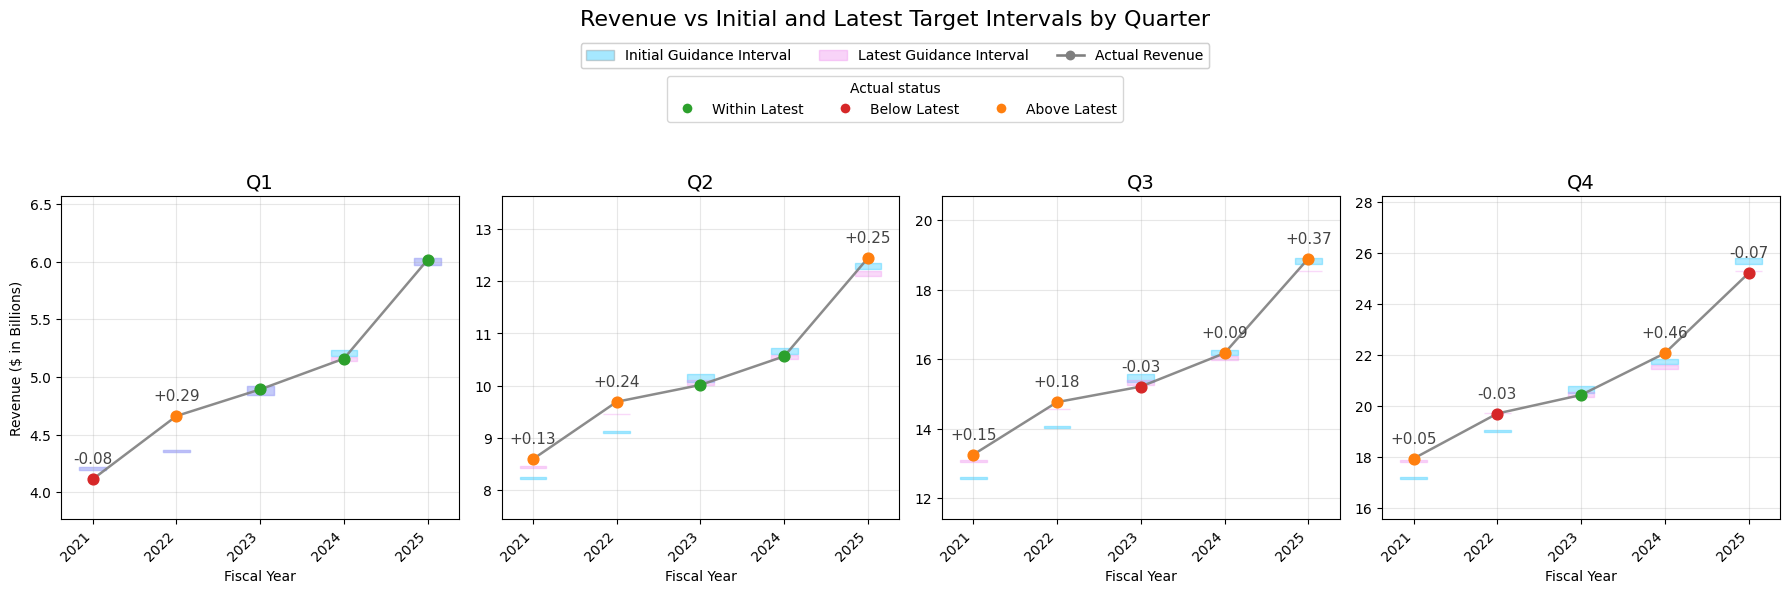

In [14]:
from src.plotting import plot_revenue_interval_actual_by_quarter

fig, axes = plot_revenue_interval_actual_by_quarter(plot_df)
plt.show()

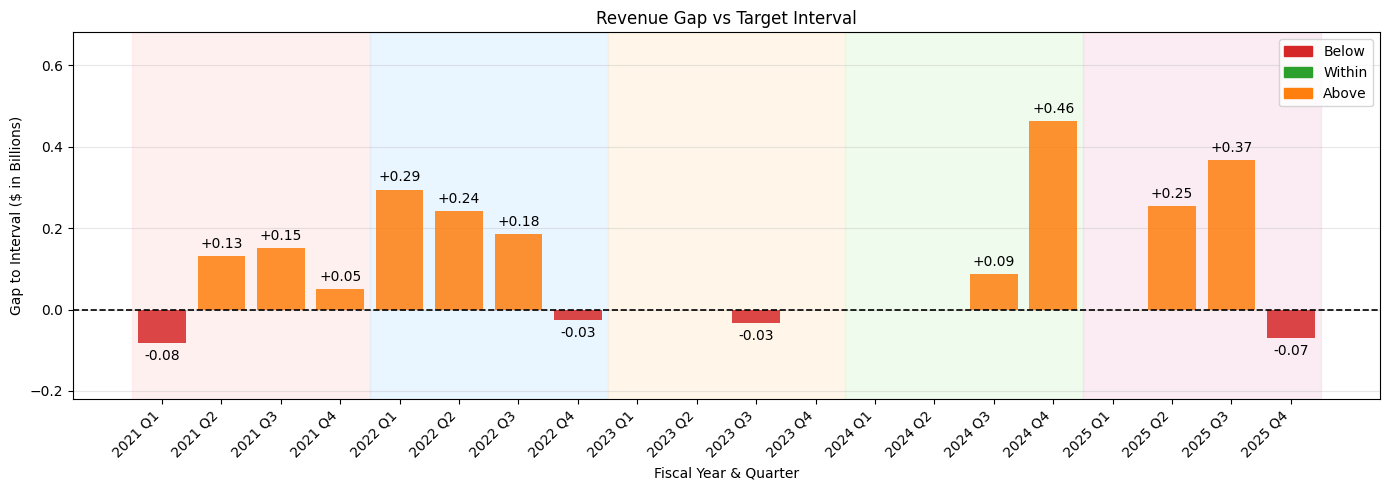

In [116]:
from src.plotting import plot_revenue_gap_to_interval

fig, axes = plot_revenue_gap_to_interval(plot_df, by='all')
plt.show()

In [15]:
from src.analysis import build_revenue_revision_table, summarize_revenue_revisions
from IPython.display import display, Markdown

revenue_revision_df = build_revenue_revision_table(result_df)
revenue_revision_summary = summarize_revenue_revisions(revenue_revision_df)

DIRECTION_EMOJI = {"up": "🔺", "down": "🔻", "mixed": "↔️"}
DIRECTION_COLOR = {"up": "#d4edda", "down": "#f8d7da", "mixed": "#fff3cd"}

rows = []
for _, r in revenue_revision_df.iterrows():
    delta = r["delta_revenue_mid_M"]
    # Use midpoint delta to determine display direction (overrides "mixed")
    if delta > 50:
        direction = "up"
    elif delta < -50:
        direction = "down"
    else:
        direction = r["revision_direction"]   # keep "mixed" only for near-zero delta
    delta_str = f"+${delta:,.0f}M" if delta >= 0 else f"-${abs(delta):,.0f}M"
    rows.append({
        "Revision Quarter": f"{int(r['curr_guidance_year'])} {r['curr_guidance_quarter']}",
        "Target Year":      int(r["target_year"]),
        "Direction":        f"{DIRECTION_EMOJI.get(direction, '')} {direction.upper()}",
        "Prior Guidance":   f"${r['prev_revenue_min_M']/1e3:.2f}B – ${r['prev_revenue_max_M']/1e3:.2f}B",
        "Updated Guidance": f"${r['curr_revenue_min_M']/1e3:.2f}B – ${r['curr_revenue_max_M']/1e3:.2f}B",
        "Δ Mid-point":      delta_str,
        "_direction":       direction,
    })

display_df = pd.DataFrame(rows)
colors = display_df["_direction"].map(DIRECTION_COLOR).fillna("#ffffff")

def _row_color(row):
    return [f"background-color: {colors.iloc[row.name]}"] * len(row)

styled = (
    display_df.drop(columns=["_direction"])
    .style
    .apply(_row_color, axis=1)
    .set_properties(**{"text-align": "center", "font-size": "13px"})
    .set_table_styles([
        {"selector": "th", "props": [("background-color", "#343a40"), ("color", "white"),
                                      ("font-size", "13px"), ("text-align", "center")]},
        {"selector": "td", "props": [("padding", "6px 12px")]},
    ])
    .hide(axis="index")
)

display(Markdown("### Revenue Guidance Revision Summary"))
display(styled)

### Revenue Guidance Revision Summary

Revision Quarter,Target Year,Direction,Prior Guidance,Updated Guidance,Δ Mid-point
2021 Q2,2021,🔺 UP,$17.12B – $17.20B,$17.58B – $17.65B,+$457M
2021 Q3,2021,🔺 UP,$17.58B – $17.65B,$17.81B – $17.88B,+$228M
2022 Q2,2022,🔺 UP,$18.97B – $19.04B,$19.72B – $19.72B,+$717M
2023 Q2,2023,🔻 DOWN,$20.49B – $20.78B,$20.34B – $20.54B,-$197M
2024 Q1,2024,🔻 DOWN,$21.65B – $21.86B,$21.45B – $21.60B,-$230M
2025 Q2,2025,🔻 DOWN,$25.55B – $25.80B,$25.27B – $25.48B,-$300M
2025 Q3,2025,🔻 DOWN,$25.27B – $25.48B,$25.27B – $25.27B,-$100M


In [ ]:
from IPython.display import display, Markdown
from langchain_ollama.llms import OllamaLLM
from langchain_core.prompts import ChatPromptTemplate
from src.earning_release_vector import get_retriever

model = OllamaLLM(model="llama3.2")

template = """
You are an expert analyst answering questions about Waste Management's quarterly
earnings call transcripts.

Fiscal period in scope: {period}

Each excerpt below is tagged with an opaque source id like [S1], [S2], etc.
Rules:
- When you use information from an excerpt, cite its id exactly as written,
  e.g. "...revenue guidance was raised [S2]".
- Every factual claim in your answer must end with at least one [S#] citation.
- Do NOT invent speaker names, numbers, or quotes that are not in the excerpts.
- If the excerpts don't contain the answer, say so explicitly.

Excerpts:
{excerpts}

Question: {question}
"""
prompt = ChatPromptTemplate.from_template(template)
chain = prompt | model

CITE_RE = re.compile(r'\[?\(?\b[Ss](\d+)\b\)?\]?')
BAD_CITE_RE = re.compile(r"\[S[^\d\]][^\]]*\]")


def format_excerpts(docs):
    return "\n\n".join(f"[S{i + 1}]\n{d.page_content}" for i, d in enumerate(docs))


def citation_for(doc):
    m = doc.metadata
    return f"[{m['period']} | {m.get('speaker', 'Unknown')} | line {m.get('line_start', '?')}]"


def resolve_citations(text, docs):
    def sub(match):
        idx = int(match.group(1)) - 1
        return citation_for(docs[idx]) if 0 <= idx < len(docs) else match.group(0)
    return CITE_RE.sub(sub, BAD_CITE_RE.sub("", text))


def _render(question, period, docs, raw):
    resolved = resolve_citations(raw, docs)
    cited_idxs = sorted({int(m) for m in CITE_RE.findall(raw) if 0 < int(m) <= len(docs)})
    scope = period or "All quarters"

    parts = [f"> 💬 *{question}*", "", f"### Scope: {scope}", "", resolved, ""]

    if cited_idxs:
        parts.append("**Cited excerpts:**")
        for i in cited_idxs:
            d = docs[i - 1]
            m = d.metadata
            snippet = d.page_content.strip().replace("\n", " ")
            # if len(snippet) > 400:
            #     snippet = snippet[:400] + "..."
            parts.append(
                f"\n> **[S{i}]** `{m['source']}` / *{m.get('speaker','?')}* "
                f"· line {m.get('line_start','?')}  \n> {snippet}"
            )
    else:
        parts.append("**Cited excerpts:** *(no [S#] citations found in the answer)*")

    display(Markdown("\n".join(parts)))


while True:
    try:
        period = input("Fiscal period (e.g., 2023Q2, blank for all): ").strip() or None
        question = input("Ask your question (q to quit): ").strip()
    except EOFError:
        break
    if question.lower() in ("q", "quit", "exit", ""):
        break

    docs = get_retriever(period=period).invoke(question)
    raw = chain.invoke({
        "period": period or "all available quarters",
        "excerpts": format_excerpts(docs),
        "question": question,
    })
    _render(question, period, docs, raw)

> 💬 *Has the total revenue forecast been adjusted? Why it's been revised?*

### Scope: 2025Q2

The company has confirmed that its revenue guidance for the year remains intact, with a small adjustment downward due to factors outside of their control, including recycled commodity prices and harsh winter weather in Q1. Specifically, they expect revenue to be about 1% below initial expectations [2025Q2 | Devina A. Rankin | line 14].

**Cited excerpts:**

> **[S5]** `2025Q2.txt` / *Devina A. Rankin* · line 14  
> ack to achieve our upwardly revised free cash flow guidance for the year. Through the first 2 quarters of 2025, we returned $669 million to shareholders and dividends and allocated $378 million to solid waste acquisitions. Our leverage ratio at the end of the quarter was 3.5x. We remain focused on quickly getting back to targeted leverage levels through a combination of earnings growth and debt reduction, and we currently project we will achieve our target in the first half of 2026. With half of 2025 complete and confidence in our continued ability to deliver on strategic priorities, we're confirming and updating our 2025 guidance. We've always said that operating EBITDA and free cash flow are the 2 best measures of performance, and we're positioned to deliver results that need meet or exceed our initial guidance for each of these measures in 2025. We're affirming the midpoint of operating EBITDA guidance of $7.55 billion and increasing our expectations for 2025 free cash flow to between $2.8 billion and $2.9 billion. Revenue for the year will be about 1% below our initial expectations due to a couple of factors outside of our control, recycled commodity prices and the harsh winter weather of the first quarter. Our team's focus on optimizing what we control, delivering on our top strategic priorities and reducing our cost to serve, position us to overcome this small revenue headwind and deliver more than 15% EBITDA growth in the year. Our strong collection and disposal operat

> 💬 *What were the key achievements of this quarter?What risks are we currently facing?*

### Scope: 2021Q3

The key achievements of this quarter include:

* Strong revenue results, with collection and disposal volume growing by 3.8% and commercial volume up 4.6%, as well as special waste volume increasing by 16.6% [2021Q3 | John Morris | line 11].
* Solid customer metrics, including service increases outpacing service decreases for the second consecutive quarter, churn at 8.7%, and year-to-date net new business for small and medium-sized business customers being up more than 10% [2021Q3 | John Morris | line 11].
* Integration of advanced disposal continuing smoothly, with around 70% of acquired operations combined into billing and operational systems [2021Q3 | John Morris | line 11].
* Achieving nearly $60 million in annual run rate synergies during the third quarter, bringing the year-to-date total to $60 million, and on track to reach $100 million by the end of the year [2021Q3 | John Morris | line 11].

As for the risks currently facing Waste Management, some of the challenges mentioned include:

* High inflation, including labor and supply chain constraints, with disbursement inflation accelerating through the third quarter and underlying labor inflation for the quarter being 8.7% [2021Q3 | Jim Fish | line 8].
* Supply chain shortages, which present an opportunity to move more decisively in strategic areas such as automation, sustainability, and workforce planning [2021Q3 | Jim Fish | line 8].

It's worth noting that these challenges are expected to be managed through pricing adjustments, reducing most expensive truck off the road, and investing in recycling technology and equipment.

**Cited excerpts:**

> **[S1]** `2021Q3.txt` / *Jim Fish* · line 8  
> Thanks, Ed. Thank you all for joining us. Our third quarter performance highlighted the exceptional cash-generation capability of our business model as we generated nearly $1.2 billion of cash from operations. Our solid results put us on track to meet the higher full-year financial outlook we provided last quarter, even as we face some of the highest inflation that we've seen in years, along with the labor and supply chain constraints. Virtually, no segment of economy, including government and the private sector, has been unaffected by these historically accrued inflationary and supply chain challenges.  Disbursement inflation accelerated through the third quarter and during the quarter, we saw roughly $60 million of labor inflation at about $100 million of inflation in other operating cost categories. Overall, our underlying labor inflation for the third quarter was 8.7%. So that's the tough news. The good news is that the business continues to perform well as demonstrated by the fact that we still expect to finish the year within our previously adjusted operating EBITDA raise, adjusted operating EBITDA, and free cash flow guidance ranges. And we will be above our prior revenue range due to strong price execution and strengthening volumes. John, Devina, and I will discuss what we're doing about these labor and inflationary pressures in the short-term and medium-term.  Not surprisingly, our disciplined price programs are the primary lever to combat cost inflation. Our pricing

> **[S2]** `2021Q3.txt` / *John Morris* · line 11  
> r adjusting for increased training hours. The fundamentals of our business remain strong and we are committed to recovering our cost increases through pricing and again, taking the most expensive truck off the road and reducing most expensive hour of the day. Now I want to focus on several of the positives in the quarter.  Turning to our strong revenue results, third-quarter collection and disposal volume grew by 3.8%, which outpaced our expectations. We continue to see strong volume driven by economic reopening with commercial volume up 4.6% and special waste volume up by 16.6%. And we see runway for continued solid performance in the fourth quarter. Customer metrics were also strong in the quarter. Service increase is outpaced, service decreases by more than twofold for the second consecutive quarter and churn was 8.7%. Year-to-date net new business for small and medium business customers is up more than 10%. Finally, our integration of advanced disposal continues to go smoothly.  We've combined around 70% of the acquired operations into our billing and operational systems and we remain on track to migrate virtually all the ADS customers by the end of the year. We have achieved nearly 26 million in annual run rate synergies during the third quarter, bringing the year-to-date total to $60 million combined with the $15 million of annual run rate synergies realized in the Fourth Quarter of 2020, we're on track to reach $100 million by the end of the year. And we continue to fo

> **[S3]** `2021Q3.txt` / *Jim Fish* · line 8  
> r shortage headwinds.  And we managed our way through it well and still expect to achieve results within our 2021 guidance ranges. And this challenge presents an opportunity for us to move more decisively in those strategic areas of automation, sustainability, and workforce planning to further separate ourselves in this industry. In conclusion, I'd like to thank the nearly 50,000 people [Indiscernible]. They continue to deliver driving another quarter of double-digit growth in revenue, operating EBITDA, and free cash flow. I'll now turn the call over to John to discuss our operational results for the quarter.